### FESOM IFS_4.4-FESOM_5-cycle3 Next Gems

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pylab as plt
import matplotlib.cm as cm
import cmocean.cm as cmo
from scipy.interpolate import CloughTocher2DInterpolator, LinearNDInterpolator, NearestNDInterpolator
import gribscan
import intake
from scipy.interpolate import griddata

## Functions

In [2]:
def season_mean(data):

    ss = data['time'].dt.season
    ss_means = data.groupby(ss).mean('time')
    return ss_means

def monthly_mean(data):
    
    season = data.groupby('time.month').mean(dim='time')
    return season

### Mesh

In [4]:
ds_mesh = xr.open_dataset('mesh_NG/IFS_4.4-FESOM_5-cycle3_mesh.nc')
ds_mesh

<xarray.Dataset> Size: 885MB
Dimensions:           (nod2: 7402886, n3: 3, elem: 14741520, nz: 70, nz1: 70)
Coordinates:
  * nod2              (nod2) int64 59MB 1 2 3 4 ... 7402884 7402885 7402886
  * elem              (elem) int64 118MB 1 2 3 4 ... 14741518 14741519 14741520
  * n3                (n3) int64 24B 0 1 2
  * nz                (nz) int64 560B 0 5 10 15 20 ... 5150 5400 5650 6000 6350
  * nz1               (nz1) float64 560B 2.5 7.5 12.5 ... 6.175e+03 6.175e+03
    elem_center_lons  (elem) float64 118MB ...
    elem_center_lats  (elem) float64 118MB ...
Data variables:
    lat               (nod2) float64 59MB ...
    lon               (nod2) float64 59MB ...
    face_nodes        (n3, elem) int64 354MB ...

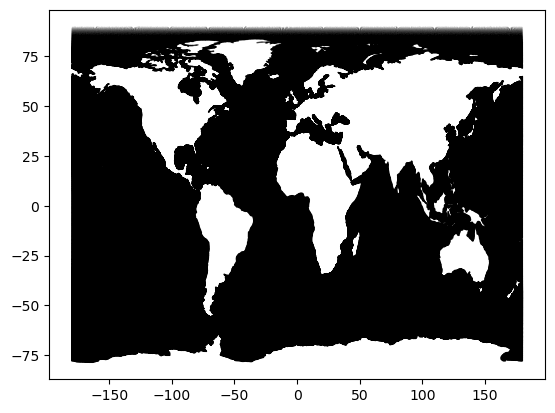

In [5]:
plt.scatter(ds_mesh['elem_center_lons'], ds_mesh['elem_center_lats'], s=1, alpha=0.05, edgecolor="none", facecolor="k")

### Xoak search

In [6]:
import xoak
ds_mesh.xoak.set_index(["elem_center_lats", "elem_center_lons"], "sklearn_geo_balltree")

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xoak/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [8]:
grid_lon = xr.DataArray(np.linspace(-180, 180, 360*4), dims=("grid_lon", ))
grid_lat = xr.DataArray(np.linspace(-90, 90, 180*4), dims=("grid_lat", ))

target_lon, target_lat = xr.broadcast(grid_lon, grid_lat)

In [9]:
grid_elems = ds_mesh.xoak.sel(
    elem_center_lats=target_lat,
    elem_center_lons=target_lon,
).elem

grid_elems = grid_elems.assign_coords(
    target_lat=target_lat,
    target_lon=target_lon,
)

grid_elems = grid_elems.assign_coords(
    grid_lat=grid_lat,
    grid_lon=grid_lon,
)

grid_elems

<xarray.DataArray 'elem' (grid_lon: 1440, grid_lat: 720)> Size: 8MB
array([[  59748,   59748,   59748, ..., 5291536, 5291530, 5780576],
       [  59748,   59748,   59748, ..., 5291533, 5291530, 5780576],
       [  59748,   59748,   59748, ..., 5291533, 5291532, 5780576],
       ...,
       [  59748,   59748,   59748, ..., 5291536, 5291530, 5780576],
       [  59748,   59748,   59748, ..., 5291536, 5291530, 5780576],
       [  59748,   59748,   59748, ..., 5291536, 5291530, 5780576]],
      shape=(1440, 720))
Coordinates:
    elem              (grid_lon, grid_lat) int64 8MB 59748 59748 ... 5780576
    elem_center_lons  (grid_lon, grid_lat) float64 8MB -163.7 -163.7 ... -162.4
    elem_center_lats  (grid_lon, grid_lat) float64 8MB -78.6 -78.6 ... 89.97
    target_lat        (grid_lon, grid_lat) float64 8MB -90.0 -89.75 ... 90.0
    target_lon        (grid_lon, grid_lat) float64 8MB -180.0 -180.0 ... 180.0
  * grid_lat          (grid_lat) float64 6kB -90.0 -89.75 -89.5 ... 89.75 90.0
  * grid_lon          (grid_lon) float64 12kB -180.0 -179.7 ... 179.7 180.0

In [31]:
ds_mesh = ds_mesh.assign_coords(
        lat=("nod2", ds_mesh.lat.data.flatten()),
        lon=("nod2", ds_mesh.lon.data.flatten()),
    )
    # Ensure the xoak index 
ds_mesh.xoak.set_index(["lat", "lon"], "sklearn_geo_balltree")

#-------------get the nod2grids
grid_nodes = ds_mesh.xoak.sel(
        lat = target_lat,
        lon = target_lon,
    ).nod2
grid_nodes

<xarray.DataArray 'nod2' (grid_lon: 1440, grid_lat: 720)> Size: 8MB
array([[  29590,   29590,   29590, ..., 4497231, 2648152, 2897521],
       [  29590,   29590,   29590, ..., 4497231, 2648152, 2897521],
       [  29590,   29590,   29590, ..., 4497231, 2648152, 2897521],
       ...,
       [  29590,   29590,   29590, ..., 4497231, 2648152, 2897521],
       [  29590,   29590,   29590, ..., 4497231, 2648152, 2897521],
       [  29590,   29590,   29590, ..., 4497231, 2648152, 2897521]],
      shape=(1440, 720))
Coordinates:
    lat      (grid_lon, grid_lat) float64 8MB -78.62 -78.62 ... 89.77 89.99
    lon      (grid_lon, grid_lat) float64 8MB -163.6 -163.6 ... -178.7 -48.1
    nod2     (grid_lon, grid_lat) int64 8MB 29590 29590 ... 2648152 2897521
Dimensions without coordinates: grid_lon, grid_lat

### Import masknan

In [24]:
masknan = xr.open_dataarray('mask_nan.nc')

## Import Data from NEXTGEMS

In [11]:
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")

In [12]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="zarr.core.metadata.v2")

ds = cat.FESOM["IFS_4.4-FESOM_5-cycle3"]["3D_daily_native"].reader.read(
    engine="netcdf4",
    chunks={
    "time": -1,     # 1 month per chunk
    "nz1": 1,      # vertical levels (e.g., 10 levels per chunk)
    "elem": -1,  # coming from ncdump -hs /work/bm1235/a270046/cycle3/tco2559l137/hzfy/hres/intel.levante.openmpi/lvt.intel.sp/Cycle3_012020/u.fesom.2020.nc
    },
)
ds = ds[['u', 'v', 'salt']]
ds

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/intake/readers/readers.py:1313: UserWarning: The specified chunks separate the stored chunks along dimension "nz1" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return open_mfdataset(ofs, **kw)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/intake/readers/readers.py:1313: UserWarning: The specified chunks separate the stored chunks along dimension "nz1" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return open_mfdataset(ofs, **kw)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/intake/readers/readers.py:1313: UserWarning: The specified chunks separate the stored chunks along dimension "nz1" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return open_mfdataset(ofs, **kw)
/work/bk1450/b383184/conda/envs/pa

<xarray.Dataset> Size: 18TB
Dimensions:  (time: 1808, nz1: 69, elem: 14741520, nod2: 7402886)
Coordinates:
    lon      (nod2) float64 59MB dask.array<chunksize=(7402886,), meta=np.ndarray>
    lat      (nod2) float64 59MB dask.array<chunksize=(7402886,), meta=np.ndarray>
  * time     (time) datetime64[ns] 14kB 2020-01-20T23:56:00 ... 2024-12-31T23...
  * nz1      (nz1) float64 552B 2.5 7.5 12.5 ... 5.525e+03 5.825e+03 6.175e+03
Dimensions without coordinates: elem, nod2
Data variables:
    u        (time, nz1, elem) float32 7TB dask.array<chunksize=(12, 1, 14741520), meta=np.ndarray>
    v        (time, nz1, elem) float32 7TB dask.array<chunksize=(12, 1, 14741520), meta=np.ndarray>
    salt     (time, nz1, nod2) float32 4TB dask.array<chunksize=(12, 1, 321865), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    history:      2022-03-19 08:26:17 GMT; Grid description file generated wi...

In [25]:
masknan

<xarray.DataArray (grid_lon: 1440, grid_lat: 720)> Size: 8MB
[1036800 values with dtype=float64]
Coordinates:
    elem              (grid_lon, grid_lat) int64 8MB ...
    elem_center_lons  (grid_lon, grid_lat) float64 8MB ...
    elem_center_lats  (grid_lon, grid_lat) float64 8MB ...
    target_lat        (grid_lon, grid_lat) float64 8MB ...
    target_lon        (grid_lon, grid_lat) float64 8MB ...
  * grid_lat          (grid_lat) float64 6kB -90.0 -89.75 -89.5 ... 89.75 90.0
  * grid_lon          (grid_lon) float64 12kB -180.0 -179.7 ... 179.7 180.0

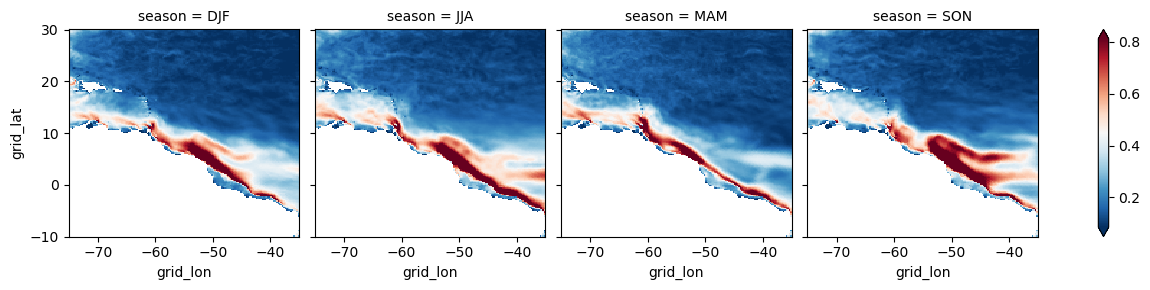

In [30]:
uv_season = xr.open_dataarray('uv_season.nc')
(uv_season * masknan).sel(grid_lon=slice(-75,-35),grid_lat=slice(-10,30)).plot(x='grid_lon', col="season", col_wrap=4,robust=True,
                                                                              cmap='RdBu_r')

In [33]:
from dask.distributed import Client
c=Client(n_workers = 3, threads_per_worker = 3)
c

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 3
Total threads: 9,Total memory: 50.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41743,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34469,Total threads: 3
Dashboard: http://127.0.0.1:35519/status,Memory: 16.67 GiB
Nanny: tcp://127.0.0.1:41479,


### Salinity

In [32]:
sal= ds.isel(nz1=0).salt.isel(nod2=grid_nodes - 1)

In [34]:
sal['lon'] = uv_season.grid_lon
sal['lat'] = uv_season.grid_lat
salt = sal.compute()
salt

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 477.51 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2025-08-14 17:17:13,000 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 13.33 GiB -- Worker memory limit: 16.67 GiB
2025-08-14 17:17:14,903 - distributed.worker.memory - WARNING - Worker is at 74% memory usage. Resuming worker. Process memory: 12.38 GiB -- Worker memory limit: 16.67 GiB


<xarray.DataArray 'salt' (time: 1808, grid_lon: 1440, grid_lat: 720)> Size: 7GB
array([[[33.81737 , 33.81737 , 33.81737 , ..., 31.557405, 31.573921,
         31.59797 ],
        [33.81737 , 33.81737 , 33.81737 , ..., 31.557405, 31.573921,
         31.59797 ],
        [33.81737 , 33.81737 , 33.81737 , ..., 31.557405, 31.573921,
         31.59797 ],
        ...,
        [33.81737 , 33.81737 , 33.81737 , ..., 31.557405, 31.573921,
         31.59797 ],
        [33.81737 , 33.81737 , 33.81737 , ..., 31.557405, 31.573921,
         31.59797 ],
        [33.81737 , 33.81737 , 33.81737 , ..., 31.557405, 31.573921,
         31.59797 ]],

       [[33.829334, 33.829334, 33.829334, ..., 31.563124, 31.578127,
         31.600765],
        [33.829334, 33.829334, 33.829334, ..., 31.563124, 31.578127,
         31.600765],
        [33.829334, 33.829334, 33.829334, ..., 31.563124, 31.578127,
         31.600765],
...
        [32.778355, 32.778355, 32.778355, ..., 32.2894  , 32.334187,
         32.387913],
        [32.778355, 32.778355, 32.778355, ..., 32.2894  , 32.334187,
         32.387913],
        [32.778355, 32.778355, 32.778355, ..., 32.2894  , 32.334187,
         32.387913]],

       [[32.64432 , 32.64432 , 32.64432 , ..., 32.294212, 32.33596 ,
         32.390644],
        [32.64432 , 32.64432 , 32.64432 , ..., 32.294212, 32.33596 ,
         32.390644],
        [32.64432 , 32.64432 , 32.64432 , ..., 32.294212, 32.33596 ,
         32.390644],
        ...,
        [32.64432 , 32.64432 , 32.64432 , ..., 32.294212, 32.33596 ,
         32.390644],
        [32.64432 , 32.64432 , 32.64432 , ..., 32.294212, 32.33596 ,
         32.390644],
        [32.64432 , 32.64432 , 32.64432 , ..., 32.294212, 32.33596 ,
         32.390644]]], shape=(1808, 1440, 720), dtype=float32)
Coordinates:
    lon       (grid_lon) float64 12kB -180.0 -179.7 -179.5 ... 179.5 179.7 180.0
    lat       (grid_lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * time      (time) datetime64[ns] 14kB 2020-01-20T23:56:00 ... 2024-12-31T2...
    nz1       float64 8B 2.5
    nod2      (grid_lon, grid_lat) int64 8MB 29590 29590 ... 2648152 2897521
  * grid_lon  (grid_lon) float64 12kB -180.0 -179.7 -179.5 ... 179.5 179.7 180.0
  * grid_lat  (grid_lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
Attributes:
    description:  salinity
    long_name:    salinity
    units:        psu

In [35]:
sal_season = season_mean(salt)
sal_season

<xarray.DataArray 'salt' (season: 4, grid_lon: 1440, grid_lat: 720)> Size: 17MB
array([[[33.639633, 33.639633, 33.639633, ..., 31.957827, 31.996513,
         31.997313],
        [33.639633, 33.639633, 33.639633, ..., 31.957827, 31.996513,
         31.997313],
        [33.639633, 33.639633, 33.639633, ..., 31.957827, 31.996513,
         31.997313],
        ...,
        [33.639633, 33.639633, 33.639633, ..., 31.957827, 31.996513,
         31.997313],
        [33.639633, 33.639633, 33.639633, ..., 31.957827, 31.996513,
         31.997313],
        [33.639633, 33.639633, 33.639633, ..., 31.957827, 31.996513,
         31.997313]],

       [[34.289906, 34.289906, 34.289906, ..., 30.634447, 30.726147,
         30.76405 ],
        [34.289906, 34.289906, 34.289906, ..., 30.634447, 30.726147,
         30.76405 ],
        [34.289906, 34.289906, 34.289906, ..., 30.634447, 30.726147,
         30.76405 ],
...
        [33.91393 , 33.91393 , 33.91393 , ..., 32.04419 , 32.085804,
         32.128872],
        [33.91393 , 33.91393 , 33.91393 , ..., 32.04419 , 32.085804,
         32.128872],
        [33.91393 , 33.91393 , 33.91393 , ..., 32.04419 , 32.085804,
         32.128872]],

       [[34.348667, 34.348667, 34.348667, ..., 31.331429, 31.323557,
         31.324522],
        [34.348667, 34.348667, 34.348667, ..., 31.331429, 31.323557,
         31.324522],
        [34.348667, 34.348667, 34.348667, ..., 31.331429, 31.323557,
         31.324522],
        ...,
        [34.348667, 34.348667, 34.348667, ..., 31.331429, 31.323557,
         31.324522],
        [34.348667, 34.348667, 34.348667, ..., 31.331429, 31.323557,
         31.324522],
        [34.348667, 34.348667, 34.348667, ..., 31.331429, 31.323557,
         31.324522]]], shape=(4, 1440, 720), dtype=float32)
Coordinates:
    lon       (grid_lon) float64 12kB -180.0 -179.7 -179.5 ... 179.5 179.7 180.0
    lat       (grid_lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
    nz1       float64 8B 2.5
    nod2      (grid_lon, grid_lat) int64 8MB 29590 29590 ... 2648152 2897521
  * grid_lon  (grid_lon) float64 12kB -180.0 -179.7 -179.5 ... 179.5 179.7 180.0
  * grid_lat  (grid_lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * season    (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
Attributes:
    description:  salinity
    long_name:    salinity
    units:        psu

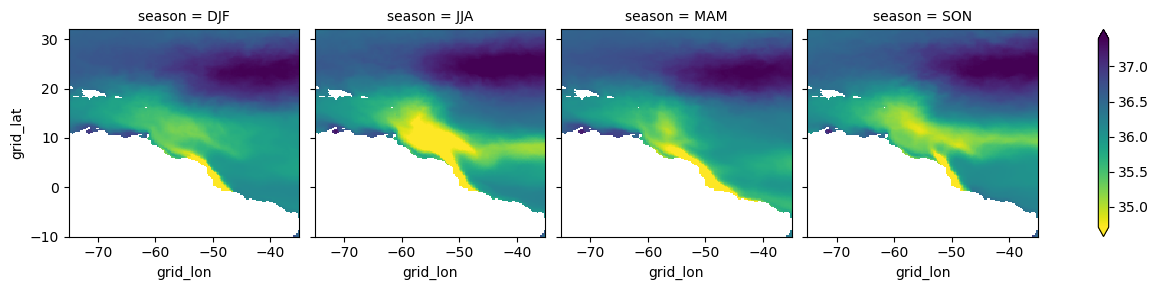

In [37]:
(sal_season * masknan).sel(grid_lon=slice(-75,-35), grid_lat=slice(-10,32)).plot(
    x="grid_lon", y="grid_lat", col="season", col_wrap=4,cmap='viridis_r',robust=True)

In [40]:
sal_mm = monthly_mean((salt * masknan).sel(grid_lon=slice(-75,-35), grid_lat=slice(-10,32)))
sal_mm

<xarray.DataArray (month: 12, grid_lon: 160, grid_lat: 168)> Size: 3MB
array([[[        nan,         nan,         nan, ..., 36.51442093,
         36.51251145, 36.50761175],
        [        nan,         nan,         nan, ..., 36.51465755,
         36.5142597 , 36.51509198],
        [        nan,         nan,         nan, ..., 36.51006581,
         36.50958734, 36.50960255],
        ...,
        [36.58308674,         nan,         nan, ..., 36.57597228,
         36.55769113, 36.54821219],
        [36.50978302, 36.52022886, 36.49581735, ..., 36.59648696,
         36.57214176, 36.55976279],
        [36.51962536, 36.48933753, 36.47328781, ..., 36.6150322 ,
         36.59242226, 36.57815961]],

       [[        nan,         nan,         nan, ..., 36.54346993,
         36.53700718, 36.52704819],
        [        nan,         nan,         nan, ..., 36.54069882,
         36.53624398, 36.52662242],
        [        nan,         nan,         nan, ..., 36.54254956,
         36.53681476, 36.5246935 ],
...
        [36.67937823,         nan,         nan, ..., 36.63921565,
         36.66092318, 36.64187037],
        [36.5321583 , 36.61640371, 36.59324397, ..., 36.6482488 ,
         36.65537422, 36.64166807],
        [36.48647316, 36.48315295, 36.54392476, ..., 36.69091011,
         36.66432353, 36.65351013]],

       [[        nan,         nan,         nan, ..., 36.55118935,
         36.54721965, 36.52997136],
        [        nan,         nan,         nan, ..., 36.55011274,
         36.55063469, 36.54091388],
        [        nan,         nan,         nan, ..., 36.54985642,
         36.548376  , 36.54059015],
        ...,
        [36.62029859,         nan,         nan, ..., 36.61447087,
         36.60575889, 36.60081612],
        [36.54699242, 36.58507425, 36.5769672 , ..., 36.6600186 ,
         36.61753405, 36.6097942 ],
        [36.53434943, 36.5235117 , 36.54434367, ..., 36.66917277,
         36.63511261, 36.62215143]]], shape=(12, 160, 168))
Coordinates:
    lon               (grid_lon) float64 1kB -74.93 -74.68 ... -35.4 -35.15
    lat               (grid_lat) float64 1kB -9.889 -9.638 ... 31.67 31.92
    nz1               float64 8B 2.5
    nod2              (grid_lon, grid_lat) int64 215kB 1876355 ... 3333395
  * grid_lon          (grid_lon) float64 1kB -74.93 -74.68 ... -35.4 -35.15
  * grid_lat          (grid_lat) float64 1kB -9.889 -9.638 ... 31.67 31.92
    elem              (grid_lon, grid_lat) int64 215kB ...
    elem_center_lons  (grid_lon, grid_lat) float64 215kB ...
    elem_center_lats  (grid_lon, grid_lat) float64 215kB ...
    target_lat        (grid_lon, grid_lat) float64 215kB ...
    target_lon        (grid_lon, grid_lat) float64 215kB ...
  * month             (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

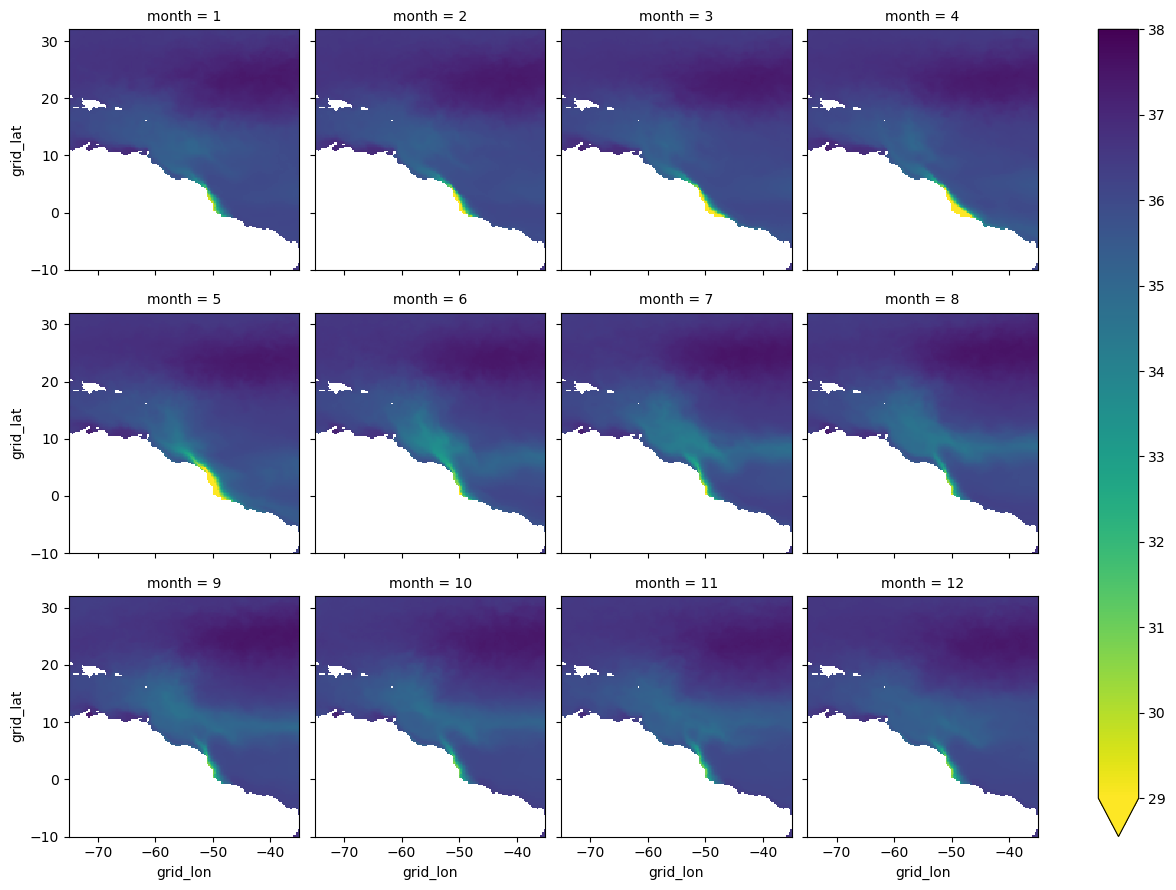

In [44]:
sal_mm.plot(x='grid_lon',col="month", col_wrap=4,cmap='viridis_r',vmin=29,vmax=38)

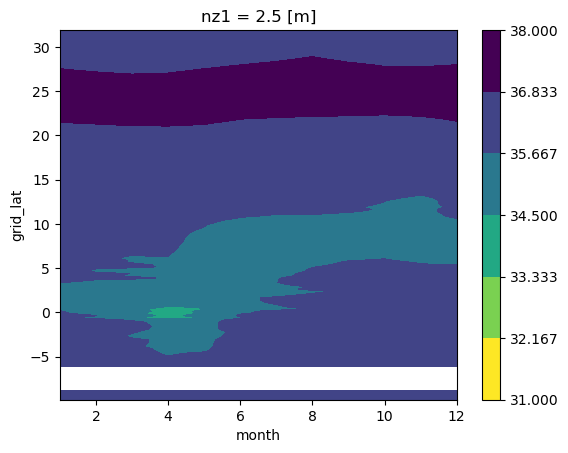

In [51]:
sal_mm.mean(dim='grid_lon').plot.contourf(x='month',y='grid_lat',cmap='viridis_r',vmin=31,vmax=38)

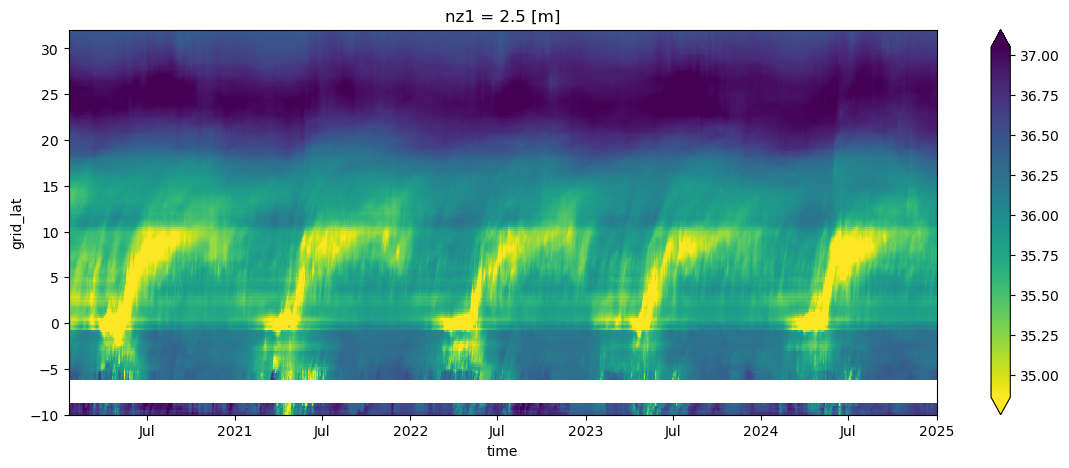

In [57]:
(salt * masknan).sel(grid_lon=slice(-75,-35), grid_lat=slice(-10,32)).mean(dim='grid_lon').plot(figsize=(14,5),
    x='time',y='grid_lat',cmap='viridis_r',robust=True)